# Solve differential-algebraic equations

Solve a differential-algebraic equation, namely, the Robertson problem.
The Robertson problem is interesting for many reasons:
  - It comes in DAE, and ODE form
    so we can compare different information operators
  - It has an exponential timescale so (good) adaptive
    steps are needed; fixed steps are hopeless.
  - Its y-states have wildly different scales,
    so a good prior model is important.

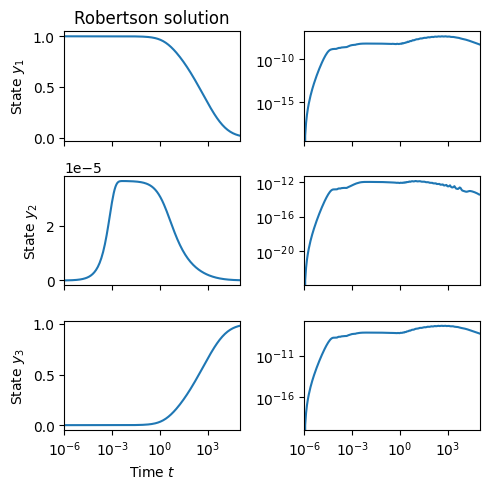

In [1]:
"""Solve a differential-algebraic equation."""

import statistics
from collections.abc import Callable

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate

from probdiffeq import ivpsolve, probdiffeq, taylor
from probdiffeq.util import nlstsq_util

# Fail this notebook on NaN detection (to catch those in the CI)
jax.config.update("jax_debug_nans", True)


def main(t0=1e-6, t1=1e5) -> None:
    """Run the script."""
    # Set up all the configs
    jax.config.update("jax_enable_x64", True)

    def differential(u, du, /, *, t):
        del t
        return du[:2] - dynamics(u)

    def dynamics(y):
        k1, k2, k3 = 0.04, 3e7, 1e4
        f0 = -k1 * y[0] + k3 * y[1] * y[2]
        f1 = k1 * y[0] - k2 * y[1] ** 2 - k3 * y[1] * y[2]
        return jnp.stack([f0, f1])

    def algebraic(u, *, t):
        del t
        return u[0] + u[1] + u[2] - 1

    def differential_auto(u, du):
        return differential(u, du, t=t0)

    def algebraic_auto(u):
        return algebraic(u, t=t0)

    y0 = [jnp.array([1.0, 0.0, 0.0])]
    nlstsq = nlstsq_util.nlstsq_constrained_gauss_newton(maxiter=10, tol=1e-8)
    y0, _info = taylor.daejet_nonlinear_lstsq(
        differential_auto, algebraic_auto, y0, num=4, nlstsq=nlstsq
    )
    init, ssm = probdiffeq.ssm_taylor(y0)

    # This base scale is critical to Robertson, because
    # the solutions live on vastly different scales
    # (but don't vary much within these scales).
    base_scale = jnp.asarray([0.8, 2e-05, 0.2])
    ioup = probdiffeq.prior_wiener_integrated(ssm=ssm, output_scale=base_scale)

    # We build a Jet constraint. Iteration is key, because DAEs are proper stiff.
    jet = probdiffeq.constraint_dae_jet(differential, algebraic, ssm=ssm, nlstsq=nlstsq)
    strategy = probdiffeq.strategy_smoother_fixedpoint(ssm=ssm)
    solver = probdiffeq.solver_dynamic(
        strategy=strategy, prior=ioup, constraint=jet, ssm=ssm
    )

    # The state-error-estimate doesn't care about the dimension
    # of the DAE, which is exactly what we need here
    error = probdiffeq.error_state_std(constraint=jet, prior=ioup, ssm=ssm)

    # Linear spacing on a log-scale
    save_at = 2.0 ** jnp.linspace(jnp.log2(t0), jnp.log2(t1), num=200)
    solve = ivpsolve.solve_adaptive_save_at(solver=solver, error=error)
    solution = jax.jit(solve)(init, save_at=save_at, atol=1e-9, rtol=1e-7)

    _fig, ax = plt.subplots(ncols=2, nrows=3, figsize=(5, 5), sharex=True)
    ax[0][0].set_title("Robertson solution")

    # Plot a special index
    i = 0
    ax[0][0].semilogx(save_at, solution.u.mean[i][:, 0] / scipy.special.factorial(i))
    ax[1][0].semilogx(save_at, solution.u.mean[i][:, 1] / scipy.special.factorial(i))
    ax[2][0].semilogx(save_at, solution.u.mean[i][:, 2] / scipy.special.factorial(i))

    ax[0][1].loglog(save_at, solution.u.std[i][:, 0] / scipy.special.factorial(i))
    ax[1][1].loglog(save_at, solution.u.std[i][:, 1] / scipy.special.factorial(i))
    ax[2][1].loglog(save_at, solution.u.std[i][:, 2] / scipy.special.factorial(i))

    ax[0][0].set_ylabel("State $y_1$")
    ax[1][0].set_ylabel("State $y_2$")
    ax[2][0].set_ylabel("State $y_3$")
    ax[2][0].set_xlabel("Time $t$")
    ax[0][0].set_xlim((t0, t1))

    plt.tight_layout()
    plt.show()


def solver_scipy(*, method: str, time_span) -> Callable:
    """Construct a solver that wraps SciPy's solution routines."""

    def vf(t, y):
        del t
        k1, k2, k3 = 0.04, 3e7, 1e4
        f0 = -k1 * y[0] + k3 * y[1] * y[2]
        f1 = k1 * y[0] - k2 * y[1] ** 2 - k3 * y[1] * y[2]
        f2 = k2 * y[1] ** 2
        return np.stack([f0, f1, f2])

    y0 = jnp.array([1.0, 0.0, 0.0])

    def param_to_solution(tol):
        solution = scipy.integrate.solve_ivp(
            vf,
            y0=y0,
            t_span=time_span,
            t_eval=time_span,
            atol=1e-3 * tol,
            rtol=tol,
            method=method,
        )
        return jnp.asarray(solution.y[:, -1])

    return param_to_solution


def rmse_relative(expected: jax.Array) -> Callable:
    """Compute the absolute RMSE."""
    expected = jnp.asarray(expected)

    def rmse(received):
        received = jnp.asarray(received)
        error_absolute = jnp.abs(expected - received)

        error_relative = error_absolute / (1e-5 + jnp.abs(expected))
        rmse = jnp.linalg.norm(error_relative) / jnp.sqrt(error_relative.size)

        algebraic = jnp.sum(received)
        return rmse, algebraic

    return rmse


def workprec(fun, *, precision_fun: Callable, work_fun: Callable) -> Callable:
    """Turn a parameter-to-solution function into parameter-to-workprecision."""

    def parameter_list_to_workprecision(list_of_args, /):
        works_mean = []
        works_std = []
        precisions = []
        for arg in list_of_args:
            precision = precision_fun(fun(arg).block_until_ready())
            work = work_fun(lambda: fun(arg).block_until_ready())  # noqa: B023

            precisions.append(precision)
            works_mean.append(statistics.mean(work))
            works_std.append(statistics.stdev(work))
        return {
            "work_mean": jnp.asarray(works_mean),
            "work_std": jnp.asarray(works_std),
            "precision": jnp.asarray(precisions),
        }

    return parameter_list_to_workprecision


main()